# Sähköverkon valvontakohteiden tiheysperusteinen klusterointi PROC MODECLUS -menetelmällä

## Yhteenveto

Sähkönjakeluyhtiö käyttää PROC MODECLUS -menetelmää löytääkseen
epäparametrisia, tiheysperusteisia klustereita verkon
valvontakohteidensa (muuntoasemat ja syöttöanturit) joukosta pelkkien
karttakoordinaattien perusteella. MODECLUS estimoi tiheyspinnan
kohteiden yli ja käsittelee klustereita korkean tiheyden alueina,
jotka erottaa matalan tiheyden kuilut. Ajettuna 90 simuloidulla
kohteella tasaisen ytimen säteellä 3 km, menetelmä palauttaa datan
sisään rakennetut kolme tiheää palvelutaskua kolmena suurimpana
klusterina (24, 24 ja 21 kohdetta), kun taas hajanaiset
maaseutukohteet putoavat harvan tiheyden alueille ja jakautuvat omiksi
yhden ja kahden kohteen mikroklustereikseen. Tuo eristettyjen kohteiden
joukko on operatiivinen lopputulos: ehdokaslista etäisistä
omaisuuseristä pääomasuunnitteluryhmälle.

## Datalähteet

| Aineisto | Rivit | Kuvaus |
|---------|------|------|
| `grid_sites` | 90 | Synteettiset sähkönjakelun valvontakohteet, luotu suoraan `call streaminit(70531)`- ja `rand()`-funktioilla. Kolme tiheää palvelutaskua (Kaupunkiydin, Esikaupunki, Teollisuusalue) piirretty kaksiulotteisista normaalijakaumista erillisten karttakeskipisteiden ympäriltä, sekä 22 hajanaista Maaseutu-kohdetta tasajakaumasta koko alueelta. |

| Muuttuja | Tyyppi | Kuvaus |
|----------|------|-------|
| `site_id` | Num | Yksilöllinen valvontakohteen tunnus (1-90). |
| `region` | Char | Suunnittelumerkintä, joka tallentaa miten kukin kohde luotiin (Kaupunkiydin, Esikaupunki, Teollisuusalue, Maaseutu); pidetään pois klusteroinnista. |
| `x_km`, `y_km` | Num | Kohteen sijainti kilometreinä sähköyhtiön suunnitteluruudukolla; klusteroinnin muuttujat. |
| `peak_load_mw` | Num | Havaittu vuotuinen huippukuorma (MW) kohteessa; mukana myöhempää tulkintaa varten. |

# Sähköverkon valvontakohteiden tiheysperusteinen klusterointi

Alueellinen sähkönjakeluyhtiö operoi verkkoa **valvontakohteista**
- muuntoasemista ja syöttöantureista - jotka on levitetty sen
palvelualueelle. Suunnittelijat haluavat ryhmitellä nämä kohteet
luonnollisiksi **palvelutaskuiksi** puhtaasti maantieteen perusteella,
määrittämättä etukäteen ryhmien lukumäärää, ja tunnistaa **eristetyt
maaseudun omaisuuserät**, jotka eivät kuulu mihinkään tiheään taskuun.

`PROC MODECLUS` sopii tähän hyvin: se tekee *epäparametrista,
tiheysperusteista* klusterointia. Se estimoi tiheysfunktion kohteiden
yli ja käsittelee sitten klustereita korkean kohdetiheyden alueina,
jotka erottaa matalan tiheyden kuilut. Harvat poikkeamat päätyvät
omiin pieniin klustereihinsa sen sijaan, että ne imeytyisivät taskuun -
juuri sellaista käytöstä haluamme etäisten kohteiden merkitsemiseen.

Tämä muistikirja:
1. Luo realistisen synteettisen 90 kohteen verkon.
2. Estimoi kohdetiheyden **tasaisella ytimellä (uniform kernel)** ja
   skannaa tasoitussäteen `R=` vahvistaakseen, että palautetut taskut
   ovat vakaita.
3. Kiinnittää työskentelysäteen, kirjoittaa `OUT=`-aineiston jokaisen
   kohteen tiheydellä ja klusterimerkinnällä, ja kartoittaa tuloksen.

## Vaihe 1 - Synteettisen valvontakohdeverkon luonti

Simuloimme 90 kohdetta. Kolme tiheää **palvelutaskua** piirretään
kaksiulotteisista normaalijakaumista erillisten karttakeskipisteiden
ympäriltä (Kaupunkiydin lähellä pistettä (12, 30), Esikaupunki lähellä
(30, 15), Teollisuusalue lähellä (20, 42)), mikä antaa tiiviit korkean
tiheyden ryppäät, joissa on 24, 24 ja 20 kohdetta. Neljäs joukko, 22
**Maaseutu**-kohdetta, piirretään tasajakaumasta koko alueelta, mikä
tuottaa harvat, hajanaiset kohteet, joita sähköyhtiö käsittelisi
eristettyinä.

`region`-merkintä tallentaa, miten kukin kohde luotiin; jätämme sen
**tarkoituksella pois** klusteroinnista, jotta MODECLUS löytää
rakenteen uudelleen pelkistä koordinaateista. `peak_load_mw` on mukana
myöhempää tulkintaa varten.

In [1]:
TIEDOT grid_sites;
   CALL streaminit(70531);
   PITUUS region $ 16;

   /* Tiheä kaupunkialueen palvelutasku */
   TEE site_id = 1 ASTI 24;
      region = 'Kaupunkiydin';
      x_km = 12 + rand('normal') * 1.3;
      y_km = 30 + rand('normal') * 1.3;
      peak_load_mw = 4.5 + rand('normal') * 0.6;
      TULOSTE;
   LOPPU;

   /* Esikaupunkitasku */
   TEE site_id = 25 ASTI 48;
      region = 'Esikaupunki';
      x_km = 30 + rand('normal') * 1.6;
      y_km = 15 + rand('normal') * 1.6;
      peak_load_mw = 2.8 + rand('normal') * 0.5;
      TULOSTE;
   LOPPU;

   /* Teollisuustasku (korkeampi huippukuorma) */
   TEE site_id = 49 ASTI 68;
      region = 'Teollisuusalue';
      x_km = 20 + rand('normal') * 1.4;
      y_km = 42 + rand('normal') * 1.4;
      peak_load_mw = 6.1 + rand('normal') * 0.8;
      TULOSTE;
   LOPPU;

   /* Hajanaiset maaseutukohteet (harvat, matala kuorma) */
   TEE site_id = 69 ASTI 90;
      region = 'Maaseutu';
      x_km = 2 + rand('uniform') * 46;
      y_km = 2 + rand('uniform') * 50;
      peak_load_mw = 0.8 + rand('uniform') * 1.2;
      TULOSTE;
   LOPPU;
SUORITA;

OTSIKKO 'Synteettiset sähköverkon valvontakohteet';
PROSEDUURI KESKIARVOT TIEDOT=grid_sites n mean std MIN MAX maxdec=2;
   LUOKKA region;
   MUUTTUJA x_km y_km peak_load_mw;
   NIMIKE region='Alue' x_km='Itäkoordinaatti (km)' y_km='Pohjoiskoordinaatti (km)'
         peak_load_mw='Huippukuorma (MW)';
SUORITA;

                                        Synteettiset sähköverkon valvontakohteet                                        

                                                  The MEANS Procedure

                                     Analysis Variable : x_km Itäkoordinaatti (km)

        Alue                    N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------------
        Esikaupunki                24          29.96           1.73          26.51          33.60
        Kaupunkiydin               24          12.07           1.34           8.65          14.42
        Maaseutu                   22          29.79          10.62          11.06          47.45
        Teollisuusalue             20          20.36           0.96          18.52          21.53
        -----------------------------------------------------------------------------------------

                                   A


NOTE: DATA grid_sites


NOTE: Wrote grid_sites (90 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Synteettiset sähköverkon valvontakohteet.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Keskiarvot vahvistavat kolme tiivistä taskua ja yhden hajanaisen
ryhmän. Kolmella tiheällä alueella on pienet koordinaattien
keskihajonnat (noin 1-1.7 km kummallakin akselilla) hyvin erillisten
keskipisteiden ympärillä, kun taas Maaseutu-ryhmä leviää koko
ruudukolle (keskihajonnat yli 10 km molemmilla akseleilla). Myös
huippukuorma erottaa taskut - Teollisuusalue-kohteet keskimäärin noin
6 MW, Kaupunkiydin noin 4.6 MW, Esikaupunki noin 2.7 MW ja
Maaseutu-kohteet noin 1.5 MW - mikä on hyödyllistä taustatietoa, kun
maantieteelliset klusterit on löydetty.

## Vaihe 2 - Tasaisen ytimen tiheysklusterointi ja sädeskannaus

Tasaisen ytimen tiheysestimointi käyttää **sädettä `R=`**: jokainen
kohde `R` kilometrin sisällä vaikuttaa kohteen paikalliseen
tiheyteen. Pieni `R` antaa väreilevän tiheyden, joka pirstoo alueen;
suuri `R` ylitasoittaa ja yhdistää taskut. Asiantunteva SAS-käyttäjä ei
koskaan luota yhteen arvoon - hän skannaa säteiden vaihteluvälin ja
etsii klusterimäärää, joka on **vakaa**, jolloin tiheät taskut
säilyvät, kun vain hajanaisten yksittäiskohteiden määrä ajelehtii.

Tässä `M=1` valitsee klusterointimenetelmän 1 (vakioepäparametrinen
menetelmä), ja pyydämme säteitä `R=2.5 to 4 by 0.5` yhdellä kutsulla.
MODECLUS ajaa analyysin kerran jokaiselle säteelle ja raportoi
klustereiden määrän kullekin. `SHORT` piilottaa yksityiskohtaiset
klusterikohtaiset tunnusluvut.

In [2]:
OTSIKKO 'Tasaisen ytimen tiheysklusterointi verkon kohteille';
title2 'Sädeskannaus R = 2.5-4.0 km';

PROSEDUURI modeclus TIEDOT=grid_sites m=1 r=2.5 ASTI 4 MUKAAN 0.5 short;
   MUUTTUJA x_km y_km;
   id site_id;
   NIMIKE x_km='Itäkoordinaatti (km)' y_km='Pohjoiskoordinaatti (km)'
         site_id='Kohteen tunnus';
SUORITA;

                                  Tasaisen ytimen tiheysklusterointi verkon kohteille                                   
                                              Sädeskannaus R = 2.5-4.0 km                                               


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: Itäkoordinaatti (km) Pohjoiskoordinaatti (km)

  Density Estimation: Bandwidth=2.5000
  Number of Clusters: 23

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Density Estimation: Bandwidth=3.5000
  Number of Clusters: 19

  Density Estimation: Bandwidth=4.0000
  Number of Clusters: 18





NOTE: Option TITLE changed to Tasaisen ytimen tiheysklusterointi verkon kohteille.
NOTE: Option TITLE2 changed to Sädeskannaus R = 2.5-4.0 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 23 Cluster(s) found. Bandwidth=2.5000 Mode-based Clustering complete.
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: Density estimation: 19 Cluster(s) found. Bandwidth=3.5000 Mode-based Clustering complete.
NOTE: Density estimation: 18 Cluster(s) found. Bandwidth=4.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Klusterimäärä muuttuu vain lievästi koko skannauksen ajan - 23
klusteria säteellä `R=2.5`, 22 säteellä `R=3.0`, 19 säteellä `R=3.5` ja
18 säteellä `R=4.0`. Korkeat raakamäärät johtuvat hajanaisista
maaseutukohteista: jokainen eristetty kohde sijaitsee omassa harvassa
naapurustossaan ja muodostaa yhden kohteen klusterin, joten suurin osa
18-23 "klusterista" on yksittäiskohteita. Se, mikä pysyy vakiona alla,
on rakenne, jolla on merkitystä - kolme tiheää taskua pysyvät kolmena
suurena, hyvin erillisenä klusterina jokaisella säteellä. `R`:n
levetessä muutama hajanainen yksittäiskohde sulautuu naapuriin tai
lähellä olevaan taskuun, minkä vuoksi kokonaismäärä ajelehtii hitaasti
alaspäin sen sijaan, että se heilahtelisi villisti. Tuo vakaus on
merkki siitä, että kolmen taskun ratkaisu on todellinen eikä yhden
kaistanleveyden artefakti.

## Vaihe 3 - Lopullinen klusteriratkaisu kartoitusta varten

Koska kolme taskua osoittautuivat vakaiksi koko skannauksen ajan,
kiinnitämme yhden työskentelysäteen (`R=3` km) ja pyydämme **ALL**-
optiota täyttä klusterikohtaista näyttöä varten, sekä **OUT=**
kirjoittaaksemme alkuperäiset koordinaatit yhdessä `DENSITY`-
estimaatin ja `CLUSTER`-merkinnän kanssa, jotta voimme kartoittaa
tuloksen. Klusterit numeroidaan laskevan moditiheyden mukaan, joten
tiheimmät taskut ovat klusterit 1, 2 ja 3, ja harvat kohteet saavat
suuremmat numerot.

In [3]:
OTSIKKO 'Lopullinen tiheysperusteinen klusteriratkaisu';
title2 'Tasainen ydin, R = 3 km';

PROSEDUURI modeclus TIEDOT=grid_sites m=1 r=3 out=join_out ALL;
   MUUTTUJA x_km y_km;
   id site_id;
   NIMIKE x_km='Itäkoordinaatti (km)' y_km='Pohjoiskoordinaatti (km)'
         site_id='Kohteen tunnus';
SUORITA;

                                     Lopullinen tiheysperusteinen klusteriratkaisu                                      
                                                Tasainen ydin, R = 3 km                                                 


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: Itäkoordinaatti (km) Pohjoiskoordinaatti (km)

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Cluster Summary
  ---------------------------------------------------------------
  Cluster   N   Mode   Mode Density
  ---------------------------------------------------------------
        1   24           5      0.009038
        2   24          46      0.007860
        3   21          56      0.007860
        4    3          83      0.001179
        5    1          29      0.000393
        6    1          69      0.000393
        7  


NOTE: Option TITLE changed to Lopullinen tiheysperusteinen klusteriratkaisu.
NOTE: Option TITLE2 changed to Tasainen ydin, R = 3 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Klusteriyhteenveto tekee rakenteen selväksi. `R=3`-ratkaisu palauttaa
**22 klusteria**, mutta ne ovat jyrkästi kerrostuneet tiheyden mukaan:

- **Klusteri 1** - 24 kohdetta, moditiheys noin 0.0090 (Kaupunkiydin-tasku).
- **Klusteri 2** - 24 kohdetta, moditiheys noin 0.0079 (Esikaupunki-tasku).
- **Klusteri 3** - 21 kohdetta, moditiheys noin 0.0079 (Teollisuusalue-tasku;
  se poimii yhden maaseutukohteen, joka sattui olemaan sen reunalla).
- **Klusteri 4** - kolmen kohteen ryhmä, moditiheys noin 0.0012, jo
  selvästi harvempi kuin kolme taskua.
- **Klusterit 5-22** - kahdeksantoista yhden kohteen klusteria, kaikki
  moditiheydellä noin 0.0004, karkeasti kaksikymmentä kertaa harvempia
  kuin taskut.

Kolme tiheää taskua kattavat 69 kohdetta 90:stä; jäljelle jäävät 21
kohdetta ovat hajanaisia maaseudun omaisuuseriä, joista jokainen
sijaitsee yksin tai lähes yksin harvan tiheyden naapurustossa. Tiheys,
ei ennalta asetettu klusterimäärä, vetää rajan palvelutaskun ja
eristetyn kohteen välille.

## Vaihe 4 - Klustereiden kartoitus

Merkitsemme jokaisen kohteen sen mukaan, osuiko se johonkin kolmesta
tiheästä taskusta (`cluster <= 3`) vai harvaan mikroklusteriin, ja
piirrämme sitten jokaisen kohteen sen karttakoordinaatteihin värjättynä
tuon tilan mukaan. Tämä on suunnittelijan näkymä: tiheät taskut
hallitaan palvelualueina, ja eristetyt kohteet merkitään erilliseen
käsittelyyn.

                                     Palautetut palvelutaskut ja erilliset kohteet                                      
                                      Tasainen ydin -tiheysklusterointi, R = 3 km                                       




NOTE: DATA mapped


NOTE: Read 90 rows from join_out.
NOTE: Wrote mapped (90 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: Option TITLE changed to Palautetut palvelutaskut ja erilliset kohteet.
NOTE: Option TITLE2 changed to Tasainen ydin -tiheysklusterointi, R = 3 km.
NOTE: PROC SGPLOT data=mapped

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


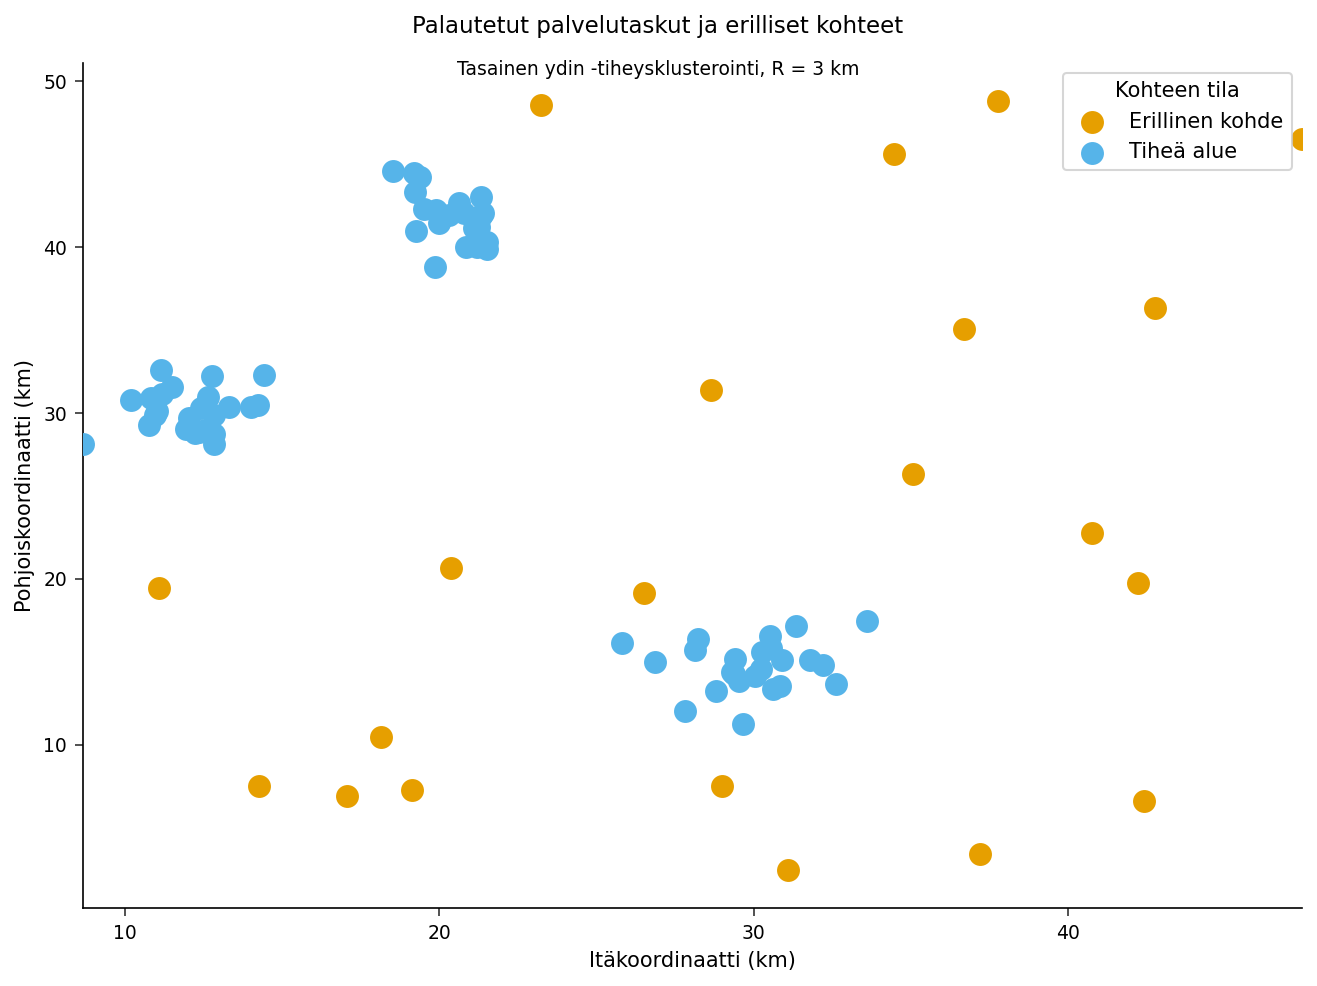

In [4]:
TIEDOT mapped;
   ASETA join_out;
   PITUUS status $ 16;
   JOS CLUSTER <= 3 NIIN status = 'Tiheä alue';
   MUUTEN status = 'Erillinen kohde';
   NIMIKE region='Alue' status='Tila' CLUSTER='Klusteri' DENSITY='Tiheys';
SUORITA;

OTSIKKO 'Palautetut palvelutaskut ja erilliset kohteet';
title2 'Tasainen ydin -tiheysklusterointi, R = 3 km';
PROSEDUURI SGPLOT TIEDOT=mapped;
   SCATTER x=x_km y=y_km / GROUP=status markerchar=CLUSTER
                           MARKERATTRS=(size=10);
   XAXIS NIMIKE='Itäkoordinaatti (km)';
   YAXIS NIMIKE='Pohjoiskoordinaatti (km)';
   keylegend / OTSIKKO='Kohteen tila';
SUORITA;

OTSIKKO;

## Tulosten tulkinta

**Mitä MODECLUS löysi.** Pelkän `(x_km, y_km)`-parin ohjaamana
menetelmä palauttaa dataan rakennetut kolme tiheää palvelutaskua -
Kaupunkiydin-, Esikaupunki- ja Teollisuusalue-ryppäät - kolmena
suurimpana, tiheimpänä klusterina (24, 24 ja 21 kohdetta). Hajanaiset
maaseutukohteet, jotka on piirretty tasajakaumasta koko alueelta,
putoavat harvan tiheyden alueille ja jakautuvat omiksi yhden ja kahden
kohteen klustereikseen sen sijaan, että ne imeytyisivät taskuun.
Kartalla ne ovat pisteitä, jotka erottuvat kolmesta tiiviistä
ryppäästä. Tuo eristetty joukko on operatiivinen lopputulos:
ehdokaslista etäisistä omaisuuseristä pääomasuunnitteluryhmälle.

**Miksi tasoitusskannaus on tärkeä.** Mikään yksittäinen `R` ei ole
auktoritatiivinen epäparametrisessa tiheysklusteroinnissa. Skannaus
`R=2.5-4.0 by 0.5` antaa meille mahdollisuuden vahvistaa, että taskut
ovat *vakaita* eri tasoitustasoilla eivätkä yhden kaistanleveyden
artefakti. Koko skannauksen ajan klusterimäärä liikkuu vain 23:sta
18:aan, ja muutos on kokonaan hajanaisten yksittäiskohteiden määrässä -
kolme tiheää taskua säilyvät koko ajan. Kun rakenne pysyi näin
vakaana, meillä on puolustettavissa oleva ratkaisu; jos määrä olisi
heilahdellut villisti, rakenne olisi hauras eikä sen pitäisi ohjata
investointipäätöksiä.

**Tiheys kerrostaa tuloksen.** Koska klusterit numeroidaan laskevan
moditiheyden mukaan, jako taskujen ja eristettyjen kohteiden välillä on
määrällinen, ei mielivaltainen: kolme taskua sijaitsevat lähellä
moditiheyttä 0.008-0.009, kun taas jokainen eristetty kohde sijaitsee
lähellä arvoa 0.0004, noin kaksikymmentä kertaa harvempana.
Suunnittelija voi asettaa tiheysrajan ja lukea eristetyt omaisuuserät
suoraan `join_out`-aineiston `CLUSTER`- ja `DENSITY`-sarakkeista.

**Käytännön hyöty.** `join_out`-aineisto antaa jokaiselle kohteelle
tiheyden ja klusterimerkinnän, joka voi käynnistää jatkotyötä -
työryhmien ja varaosien mitoitusta palvelutaskua kohti,
tarkastuskierrosten reititystä tai verkon vahvistamisen priorisointia
tiheässä teollisuusklusterissa (korkein `peak_load_mw`, noin 6 MW) -
samalla kun eristetyt maaseutukohteet aikataulutetaan erilliseen,
harvemmin toistuvaan huoltoon.

*Huomio synteettisestä datasta:* koordinaatit ja kuormat on simuloitu
kiinteällä siemenluvulla (`call streaminit(70531)`), joten muistikirja
on täysin toistettavissa offline-tilassa; todellisella
sähköyhtiödatalla korvaisit kartoitetut kohdekoordinaatit ja mitatut
huippukuormat. Tarkat klusterimäärät riippuvat satunnaispoiminnasta ja
valitusta säteestä.